In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

LOAD PROCESSED DATA 

In [13]:
X = pd.read_csv("processed_features.csv")
y = pd.read_csv("processed_target.csv").squeeze()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nPayment rate: {y.mean()*100:.1f}%")

Features (X) shape: (1000, 98)
Target (y) shape: (1000,)

Class distribution:
current_payment
0    741
1    259
Name: count, dtype: int64

Payment rate: 25.9%


TRAIN SPLIT DATA

In [14]:
if 'Billing_Num' in X.columns:
    sorted_idx = X['Billing_Num'].argsort().values
    split_idx = int(len(sorted_idx) * 0.80)

    train_indices = sorted_idx[:split_idx]
    test_indices = sorted_idx[split_idx:]

    X_train = X.iloc[train_indices].copy()
    X_test = X.iloc[test_indices].copy()
    y_train = y.iloc[train_indices].copy()
    y_test = y.iloc[test_indices].copy()

    print("Split using Billing_Num (temporal ordering, 80/20 split).")
else:
    split_idx = int(len(X) * 0.80)
    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()
    print("Billing_Num not found. Using row-order split (80/20).")

print(f"\nTraining set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Split using Billing_Num (temporal ordering, 80/20 split).

Training set size: 800 rows
Test set size: 200 rows

Training class distribution:
current_payment
0    587
1    213
Name: count, dtype: int64

Test class distribution:
current_payment
0    154
1     46
Name: count, dtype: int64


UNDERSTANDING CLASSS IMBALANCE

In [15]:
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
imbalance_ratio = n_negative / n_positive

print(f"Training set:")
print(f"  Class 0 (no payment): {n_negative}")
print(f"  Class 1 (made payment): {n_positive}")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"\nWith class_weight='balanced', the model will penalise mistakes on class 1")
print(f"by a factor of {imbalance_ratio:.2f}, making it pay more attention to payers.")

Training set:
  Class 0 (no payment): 587
  Class 1 (made payment): 213
  Imbalance ratio: 2.76:1

With class_weight='balanced', the model will penalise mistakes on class 1
by a factor of 2.76, making it pay more attention to payers.


RANDOM FOREST MODEL

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,           # no limit (we will tune this)
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                 # use all CPU cores
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

auc_rf = roc_auc_score(y_test, y_prob_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest Results (default hyperparameters, test set):")
print(f"  AUC-ROC:   {auc_rf:.4f}")
print(f"  F1-Score:  {f1_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall:    {recall_rf:.4f}")

Random Forest Results (default hyperparameters, test set):
  AUC-ROC:   0.6310
  F1-Score:  0.2529
  Precision: 0.2683
  Recall:    0.2391


CROSS VALIDATION

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
}

total_combinations = 2 * 3 * 3
print(f"Grid search: {total_combinations} combinations x 5 folds = {total_combinations * 5} model fits")
print("This may take a minute...")

cv = StratifiedKFold(n_splits=5, shuffle=False)  # shuffle=False preserves temporal order

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\nBest hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation AUC-ROC: {grid_search.best_score_:.4f}")

Grid search: 18 combinations x 5 folds = 90 model fits
This may take a minute...

Best hyperparameters found:
  max_depth: None
  min_samples_leaf: 10
  n_estimators: 100

Best cross-validation AUC-ROC: 0.6650


EVALUTE TUNED VALUE

In [18]:
best_model = grid_search.best_estimator_

y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_prob_tuned >= 0.5).astype(int)

auc_tuned = roc_auc_score(y_test, y_prob_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results (test set):")
print(f"  AUC-ROC:   {auc_tuned:.4f}")
print(f"  F1-Score:  {f1_tuned:.4f}")
print(f"  Precision: {precision_tuned:.4f}")
print(f"  Recall:    {recall_tuned:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_tuned)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Negatives  (correctly predicted no payment): {tn}")
print(f"  False Positives (predicted payment, but did not):  {fp}")
print(f"  False Negatives (predicted no payment, but did):   {fn}")
print(f"  True Positives  (correctly predicted payment):     {tp}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Payment', 'Made Payment']))

Tuned Random Forest Results (test set):
  AUC-ROC:   0.6543
  F1-Score:  0.4211
  Precision: 0.3019
  Recall:    0.6957

Confusion Matrix:
[[80 74]
 [14 32]]

  True Negatives  (correctly predicted no payment): 80
  False Positives (predicted payment, but did not):  74
  False Negatives (predicted no payment, but did):   14
  True Positives  (correctly predicted payment):     32

Full Classification Report:
              precision    recall  f1-score   support

  No Payment       0.85      0.52      0.65       154
Made Payment       0.30      0.70      0.42        46

    accuracy                           0.56       200
   macro avg       0.58      0.61      0.53       200
weighted avg       0.72      0.56      0.59       200



model comp

In [24]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest (Default)',
        'Random Forest (Tuned)'
    ],
    'AUC-ROC': [auc_rf, auc_tuned],
    'F1-Score': [f1_rf, f1_tuned],
    'Precision': [precision_rf, precision_tuned],
    'Recall': [recall_rf, recall_tuned]
}).round(4)

print(comparison)

                     Model  AUC-ROC  F1-Score  Precision  Recall
0  Random Forest (Default)   0.6310    0.2529     0.2683  0.2391
1    Random Forest (Tuned)   0.6543    0.4211     0.3019  0.6957


THRESHOLD ANALYSIS

In [25]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Accounts Flagged'}")
print("-" * 65)

for thresh in thresholds:
    y_pred_thresh = (y_prob_tuned >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh, zero_division=0)
    r = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    flagged = y_pred_thresh.sum()
    print(f"{thresh:<12} {p:<12.4f} {r:<12.4f} {f1:<12.4f} {flagged}")

Threshold    Precision    Recall       F1-Score     Accounts Flagged
-----------------------------------------------------------------
0.3          0.3151       1.0000       0.4792       146
0.4          0.3172       1.0000       0.4817       145
0.5          0.3019       0.6957       0.4211       106
0.6          0.3529       0.1304       0.1905       17
0.7          0.0000       0.0000       0.0000       0


PRECISION-RECALL CURVE 

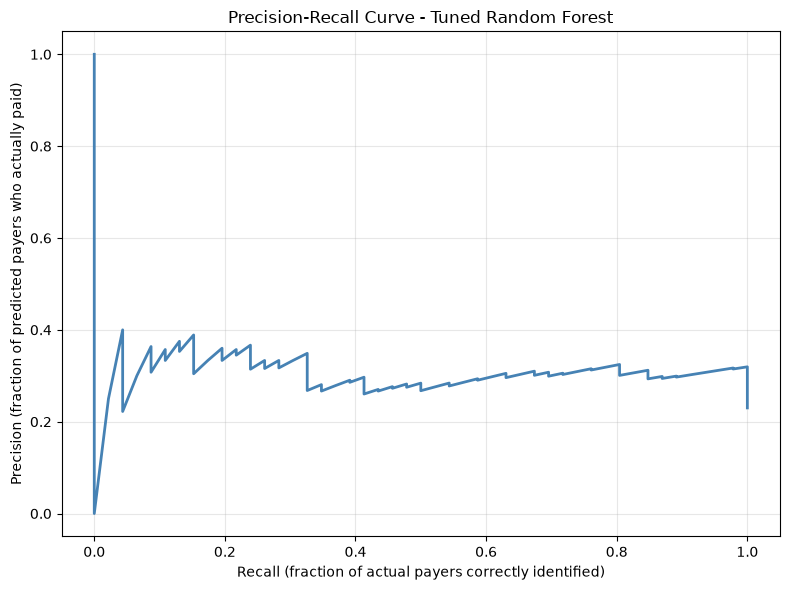

In [27]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color='steelblue', linewidth=2)
ax.set_xlabel('Recall (fraction of actual payers correctly identified)')
ax.set_ylabel('Precision (fraction of predicted payers who actually paid)')
ax.set_title('Precision-Recall Curve - Tuned Random Forest')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150, bbox_inches='tight')
plt.show()

feature imp graph

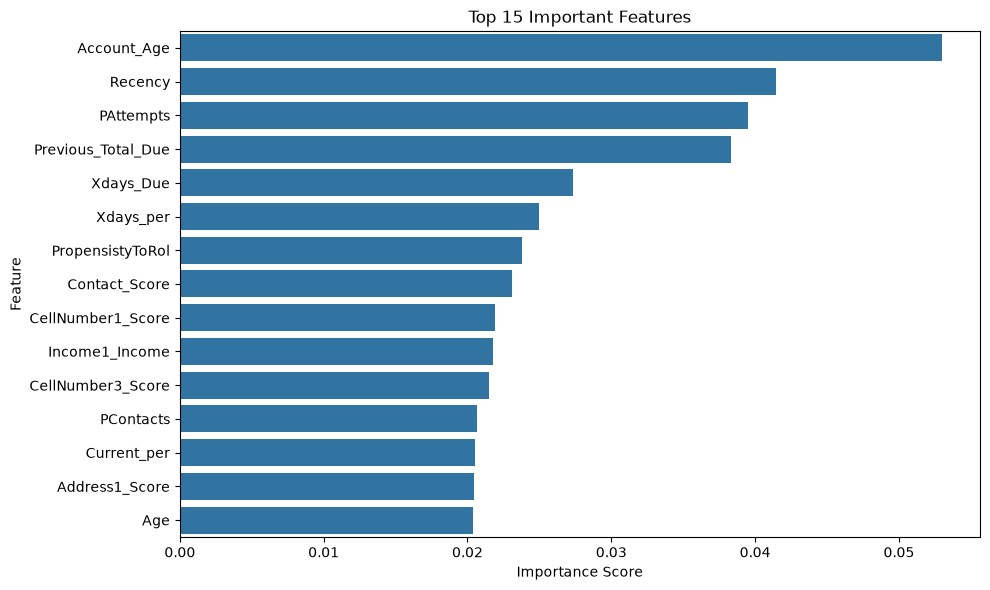

In [34]:
# FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top15 = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top15,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()